In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file
df = pd.read_csv('EWS.csv')

# Let's look at what we loaded
print("Dataset initial shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset initial shape: (1111, 44)

First few rows:
   Y       Data  XAU BGNL  ECSURPUS    BDIY     CRY     DXY     JPY    GBP  \
0  0  1/11/2000    283.25     0.077  1388.0  157.26  100.56  105.86  1.646   
1  0  1/18/2000    287.65     0.043  1405.0  165.01  101.86  105.47  1.638   
2  0  1/25/2000    287.15     0.135  1368.0  167.24  102.41  106.04  1.650   
3  0   2/1/2000    282.75     0.191  1311.0  166.85  104.92  107.85  1.611   
4  1   2/8/2000    298.40     0.312  1277.0  165.43  104.22  109.30  1.611   

     Cl1  ...  LP01TREU  EMUSTRUU  LF94TRUU     MXUS    MXEU     MXJP    MXBR  \
0  25.77  ...   116.464   230.527   123.762  1416.12  127.75   990.59  856.76   
1  28.85  ...   117.267   231.377   123.762  1428.79  129.50   993.98  925.22   
2  28.28  ...   117.995   232.390   123.762  1385.93  126.48   974.83  886.93   
3  28.22  ...   120.510   231.942   122.328  1385.31  129.19  1007.12  842.60   
4  28.02  ...   118.791   237.812   122.328  1411.95  134.67  1034.58  945.

In [4]:
columns_to_keep = ['Y', 'VIX', 'GT10', 'JPY', 'GBP', 'DXY', 'CRY']
df = df[columns_to_keep]
df

,Y,VIX,GT10,JPY,GBP,DXY,CRY
0,0,22.50,6.657,105.86,1.6460,100.560,157.2600
1,0,21.50,6.748,105.47,1.6380,101.860,165.0100
2,0,23.02,6.692,106.04,1.6500,102.410,167.2400
3,0,23.45,6.619,107.85,1.6110,104.920,166.8500
4,1,21.25,6.613,109.30,1.6110,104.220,165.4300
...,...,...,...,...,...,...,...
1106,0,20.30,1.622,108.72,1.3760,92.336,184.5022
1107,0,19.61,1.706,110.29,1.3719,93.297,184.8741
1108,0,18.12,1.658,109.88,1.3822,92.335,185.8393
1109,0,16.65,1.616,109.19,1.3737,91.852,188.1368


In [5]:
df['VIX_MA20'] = df['VIX'].rolling(window=20).mean()  # 20-day moving average
df['VIX_MA50'] = df['VIX'].rolling(window=50).mean()

df['VIX_MA20']

<ipython-input-5-a7aefeb50d34>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['VIX_MA20'] = df['VIX'].rolling(window=20).mean()  # 20-day moving average
<ipython-input-5-a7aefeb50d34>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['VIX_MA50'] = df['VIX'].rolling(window=50).mean()


,VIX_MA20
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1106,22.7855
1107,22.5260
1108,22.2965
1109,22.0470


In [6]:
df['VIX_MA20_Diff'] = df['VIX'] - df['VIX_MA20']
df['VIX_MA50_Diff'] = df['VIX'] - df['VIX_MA50']

df['VIX_MA20_Diff']

<ipython-input-6-d298616d0574>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['VIX_MA20_Diff'] = df['VIX'] - df['VIX_MA20']
<ipython-input-6-d298616d0574>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['VIX_MA50_Diff'] = df['VIX'] - df['VIX_MA50']


,VIX_MA20_Diff
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1106,-2.4855
1107,-2.9160
1108,-4.1765
1109,-5.3970


In [7]:
# Calculate how far current VIX is from its moving averages
df['VIX_MA20_Diff'] = df['VIX'] - df['VIX_MA20']
df['VIX_MA50_Diff'] = df['VIX'] - df['VIX_MA50']

df['VIX_MA20_Diff']

<ipython-input-7-c99622433eea>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['VIX_MA20_Diff'] = df['VIX'] - df['VIX_MA20']
<ipython-input-7-c99622433eea>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['VIX_MA50_Diff'] = df['VIX'] - df['VIX_MA50']


,VIX_MA20_Diff
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1106,-2.4855
1107,-2.9160
1108,-4.1765
1109,-5.3970


In [8]:
df = df.dropna()

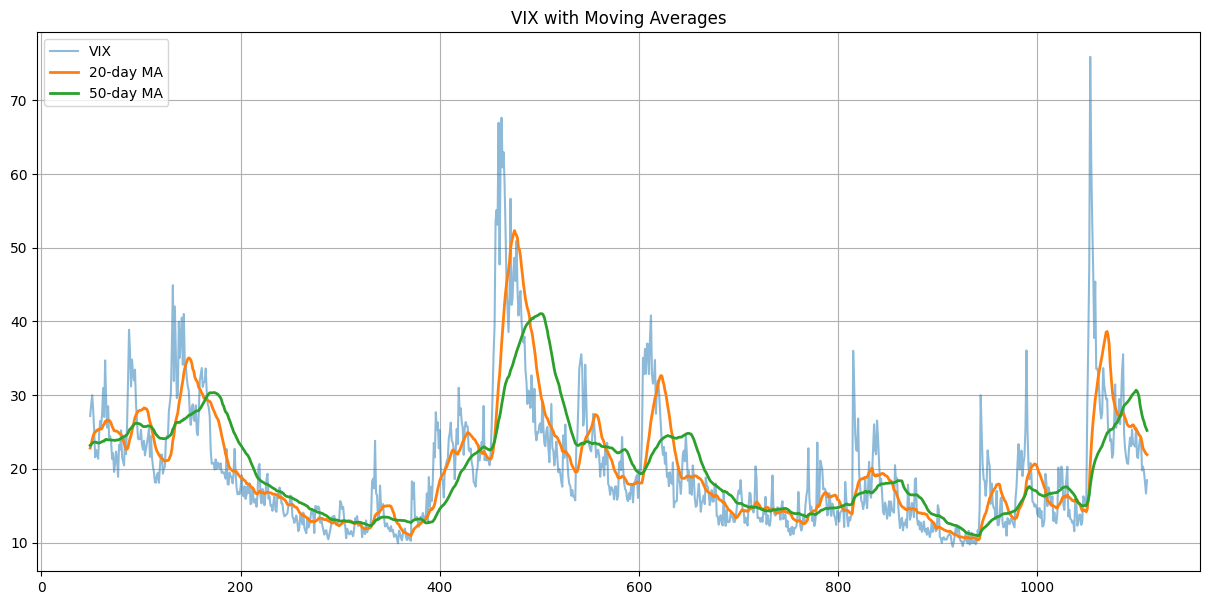

In [9]:
plt.figure(figsize=(15, 7))
plt.plot(df['VIX'], label='VIX', alpha=0.5)
plt.plot(df['VIX_MA20'], label='20-day MA', linewidth=2)
plt.plot(df['VIX_MA50'], label='50-day MA', linewidth=2)
plt.title('VIX with Moving Averages')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
print("\nCrisis vs Normal periods distribution:")
df['Y'].value_counts()


Crisis vs Normal periods distribution:


,count
Y,
0,842
1,220


<ipython-input-11-fb69e7bb4a2e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.date_range(start='2000-01-01', periods=len(df), freq='B')  # 'B' for business days


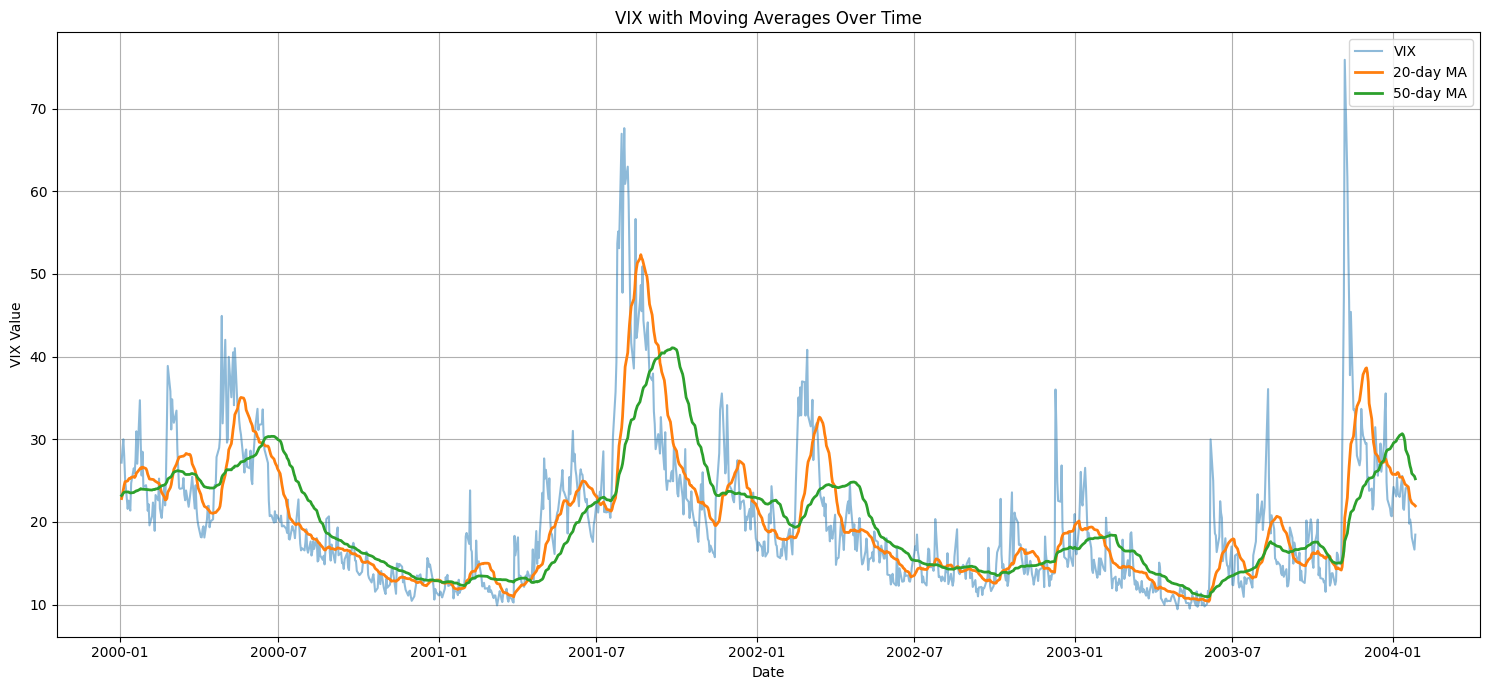

In [11]:
# Convert the index to a datetime
df['Date'] = pd.date_range(start='2000-01-01', periods=len(df), freq='B')  # 'B' for business days

# Create a new plot with dates
plt.figure(figsize=(15, 7))
plt.plot(df['Date'], df['VIX'], label='VIX', alpha=0.5)
plt.plot(df['Date'], df['VIX_MA20'], label='20-day MA', linewidth=2)
plt.plot(df['Date'], df['VIX_MA50'], label='50-day MA', linewidth=2)
plt.title('VIX with Moving Averages Over Time')
plt.xlabel('Date')
plt.ylabel('VIX Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
print("Shape of our dataset:", df.shape)

Shape of our dataset: (1062, 12)


In [13]:
df

,Y,VIX,GT10,JPY,GBP,DXY,CRY,VIX_MA20,VIX_MA50,VIX_MA20_Diff,VIX_MA50_Diff,Date
49,1,27.17,5.188,112.48,1.4640,113.210,195.6300,22.8220,23.1922,4.3480,3.9778,2000-01-03
50,1,28.73,5.036,113.65,1.4790,110.310,194.5200,23.3190,23.3168,5.4110,5.4132,2000-01-04
51,1,29.99,4.916,114.50,1.4990,108.610,192.9200,23.9195,23.4866,6.0705,6.5034,2000-01-05
52,0,27.99,5.000,116.67,1.4890,109.520,195.8200,24.4455,23.5860,3.5445,4.4040,2000-01-06
53,0,25.28,5.230,117.37,1.4680,110.110,198.5300,24.8650,23.6226,0.4150,1.6574,2000-01-07
...,...,...,...,...,...,...,...,...,...,...,...,...
1106,0,20.30,1.622,108.72,1.3760,92.336,184.5022,22.7855,26.7636,-2.4855,-6.4636,2004-01-21
1107,0,19.61,1.706,110.29,1.3719,93.297,184.8741,22.5260,26.4006,-2.9160,-6.7906,2004-01-22
1108,0,18.12,1.658,109.88,1.3822,92.335,185.8393,22.2965,25.8548,-4.1765,-7.7348,2004-01-23
1109,0,16.65,1.616,109.19,1.3737,91.852,188.1368,22.0470,25.5164,-5.3970,-8.8664,2004-01-26


In [14]:
print(df['Date'].head())

49   2000-01-03
50   2000-01-04
51   2000-01-05
52   2000-01-06
53   2000-01-07
Name: Date, dtype: datetime64[ns]


In [15]:
print(df['Date'].tail())

1106   2004-01-21
1107   2004-01-22
1108   2004-01-23
1109   2004-01-26
1110   2004-01-27
Name: Date, dtype: datetime64[ns]


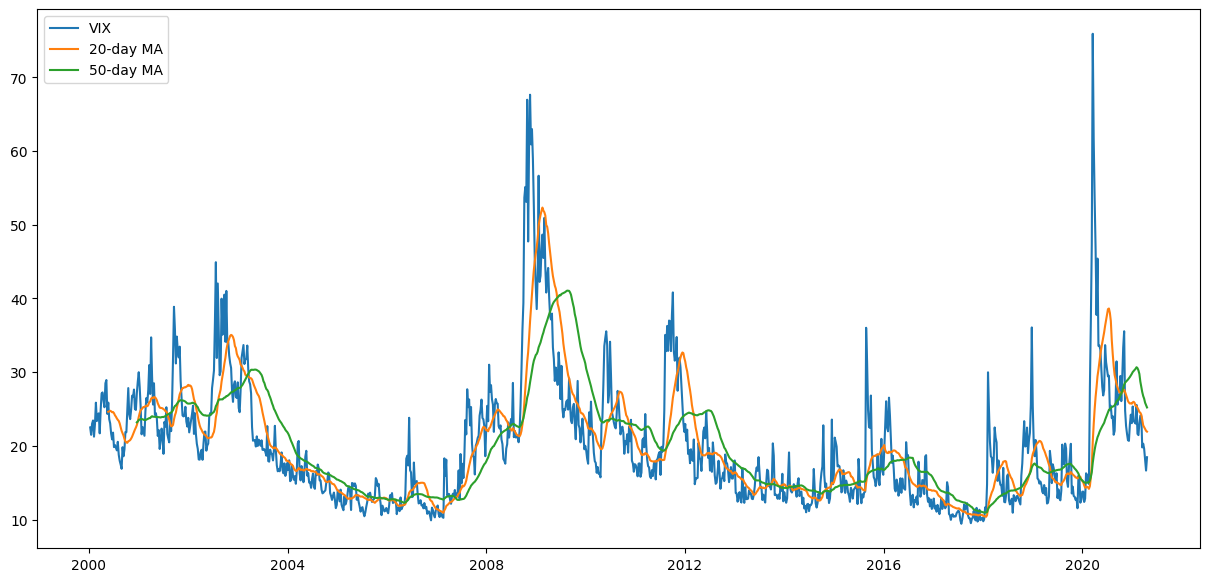

In [16]:
# Read data and convert dates
df = pd.read_csv('EWS.csv')
df['Date'] = pd.to_datetime(df['Data'])

# Calculate VIX moving averages
df['VIX_MA20'] = df['VIX'].rolling(window=20).mean()
df['VIX_MA50'] = df['VIX'].rolling(window=50).mean()

# Create basic plot
plt.figure(figsize=(15, 7))
plt.plot(df['Date'], df['VIX'], label='VIX')
plt.plot(df['Date'], df['VIX_MA20'], label='20-day MA')
plt.plot(df['Date'], df['VIX_MA50'], label='50-day MA')
plt.legend()
plt.show()


In [17]:
df


,Y,Data,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,...,MXUS,MXEU,MXJP,MXBR,MXRU,MXIN,MXCN,Date,VIX_MA20,VIX_MA50
0,0,1/11/2000,283.25,0.077,1388.0,157.2600,100.560,105.86,1.6460,25.77,...,1416.12,127.75,990.59,856.76,224.33,217.34,34.30,2000-01-11,NaN,NaN
1,0,1/18/2000,287.65,0.043,1405.0,165.0100,101.860,105.47,1.6380,28.85,...,1428.79,129.50,993.98,925.22,234.37,227.08,32.74,2000-01-18,NaN,NaN
2,0,1/25/2000,287.15,0.135,1368.0,167.2400,102.410,106.04,1.6500,28.28,...,1385.93,126.48,974.83,886.93,216.82,233.00,32.46,2000-01-25,NaN,NaN
3,0,2/1/2000,282.75,0.191,1311.0,166.8500,104.920,107.85,1.6110,28.22,...,1385.31,129.19,1007.12,842.60,201.89,237.48,31.29,2000-02-01,NaN,NaN
4,1,2/8/2000,298.40,0.312,1277.0,165.4300,104.220,109.30,1.6110,28.02,...,1411.95,134.67,1034.58,945.15,218.00,258.02,31.32,2000-02-08,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,0,3/23/2021,1727.96,0.339,2271.0,184.5022,92.336,108.72,1.3760,57.76,...,3800.77,140.32,1199.57,1671.73,681.21,1695.96,110.83,2021-03-23,22.7855,26.7636
1107,0,3/30/2021,1685.56,0.303,2103.0,184.8741,93.297,110.29,1.3719,60.55,...,3835.96,142.76,1206.29,1635.57,693.38,1690.76,108.80,2021-03-30,22.5260,26.4006
1108,0,4/6/2021,1743.28,0.440,2092.0,185.8393,92.335,109.88,1.3822,59.33,...,3955.16,144.13,1194.62,1689.62,673.20,1689.48,111.92,2021-04-06,22.2965,25.8548
1109,0,4/13/2021,1742.69,0.467,2140.0,188.1368,91.852,109.19,1.3737,60.18,...,4027.05,144.23,1197.06,1680.82,680.23,1672.46,108.40,2021-04-13,22.0470,25.5164


In [18]:
# Read data and convert dates
df = pd.read_csv('EWS.csv')
df['Date'] = pd.to_datetime(df['Data'])

# Select our important market indicators
columns_to_keep = ['Date', 'Y', 'VIX', 'GT10', 'JPY', 'GBP', 'DXY', 'CRY']
df = df[columns_to_keep]

# Calculate VIX moving averages
df['VIX_MA20'] = df['VIX'].rolling(window=20).mean()
df['VIX_MA50'] = df['VIX'].rolling(window=50).mean()

# Calculate difference between VIX and its moving averages
# This helps identify unusual market stress periods
df['VIX_MA20_Diff'] = df['VIX'] - df['VIX_MA20']
df['VIX_MA50_Diff'] = df['VIX'] - df['VIX_MA50']

# Remove any rows with missing values created by moving averages
df = df.dropna()



In [19]:
df

,Date,Y,VIX,GT10,JPY,GBP,DXY,CRY,VIX_MA20,VIX_MA50,VIX_MA20_Diff,VIX_MA50_Diff
49,2000-12-19,1,27.17,5.188,112.48,1.4640,113.210,195.6300,22.8220,23.1922,4.3480,3.9778
50,2000-12-26,1,28.73,5.036,113.65,1.4790,110.310,194.5200,23.3190,23.3168,5.4110,5.4132
51,2001-01-02,1,29.99,4.916,114.50,1.4990,108.610,192.9200,23.9195,23.4866,6.0705,6.5034
52,2001-01-09,0,27.99,5.000,116.67,1.4890,109.520,195.8200,24.4455,23.5860,3.5445,4.4040
53,2001-01-16,0,25.28,5.230,117.37,1.4680,110.110,198.5300,24.8650,23.6226,0.4150,1.6574
...,...,...,...,...,...,...,...,...,...,...,...,...
1106,2021-03-23,0,20.30,1.622,108.72,1.3760,92.336,184.5022,22.7855,26.7636,-2.4855,-6.4636
1107,2021-03-30,0,19.61,1.706,110.29,1.3719,93.297,184.8741,22.5260,26.4006,-2.9160,-6.7906
1108,2021-04-06,0,18.12,1.658,109.88,1.3822,92.335,185.8393,22.2965,25.8548,-4.1765,-7.7348
1109,2021-04-13,0,16.65,1.616,109.19,1.3737,91.852,188.1368,22.0470,25.5164,-5.3970,-8.8664


In [20]:
df['VIX'].describe()


,VIX
count,1062.000000
mean,19.848267
std,8.788862
min,9.430000
25%,13.532500
50%,17.580000
75%,23.280000
max,75.910000


In [21]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# We'll use the last 20% of our data for testing
split_index = int(len(df) * 0.8)
train_df = df[:split_index]
test_df = df[split_index:]

# Define our feature columns
feature_columns = ['VIX', 'VIX_MA20_Diff', 'VIX_MA50_Diff', 'GT10', 'JPY', 'GBP', 'DXY', 'CRY']

# Prepare train and test features
X_train = train_df[feature_columns]
X_test = test_df[feature_columns]
y_train = train_df['Y']
y_test = test_df['Y']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'IsolationForest': IsolationForest(contamination=0.2, random_state=42),
    'OneClassSVM': OneClassSVM(nu=0.2),
    'LOF': LocalOutlierFactor(contamination=0.2, novelty=True)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled)

    # Get predictions for both train and test sets
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_pred = np.where(train_pred == -1, 1, 0)
    test_pred = np.where(test_pred == -1, 1, 0)

    # Calculate metrics
    results[name] = {
        'train_f1': f1_score(y_train, train_pred),
        'test_f1': f1_score(y_test, test_pred),
        'train_precision': precision_score(y_train, train_pred),
        'test_precision': precision_score(y_test, test_pred),
        'train_recall': recall_score(y_train, train_pred),
        'test_recall': recall_score(y_test, test_pred)
    }

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print("\nModel Performance Metrics:")
print(results_df)


Model Performance Metrics:
                 train_f1   test_f1  train_precision  test_precision  \
IsolationForest  0.531856  0.494845         0.564706        0.352941   
OneClassSVM      0.493075  0.464646         0.523529        0.328571   
LOF              0.345029  0.421875         0.390728        0.272727   

                 train_recall  test_recall  
IsolationForest      0.502618     0.827586  
OneClassSVM          0.465969     0.793103  
LOF                  0.308901     0.931034  


In [25]:
best_model = models['IsolationForest']
final_predictions = best_model.predict(X_test_scaled)
final_predictions = np.where(final_predictions == -1, 1, 0)

test_df['predicted_anomaly'] = final_predictions

test_df

<ipython-input-25-8530031139c9>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_anomaly'] = final_predictions


,Date,Y,VIX,GT10,JPY,GBP,DXY,CRY,VIX_MA20,VIX_MA50,VIX_MA20_Diff,VIX_MA50_Diff,predicted_anomaly
898,2017-03-28,0,11.53,2.419,110.65,1.2480,99.712,184.0780,12.0085,13.6760,-0.4785,-2.1460,0
899,2017-04-04,0,11.79,2.361,110.69,1.2430,100.540,185.5940,11.9295,13.6470,-0.1395,-1.8570,0
900,2017-04-11,0,15.07,2.297,109.76,1.2480,100.710,187.9960,12.0625,13.6692,3.0075,1.4008,0
901,2017-04-18,0,14.42,2.169,108.46,1.2770,99.499,186.5450,12.1385,13.6456,2.2815,0.7744,0
902,2017-04-25,0,10.76,2.333,110.98,1.2840,98.785,181.9090,12.0870,13.5882,-1.3270,-2.8282,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,2021-03-23,0,20.30,1.622,108.72,1.3760,92.336,184.5022,22.7855,26.7636,-2.4855,-6.4636,0
1107,2021-03-30,0,19.61,1.706,110.29,1.3719,93.297,184.8741,22.5260,26.4006,-2.9160,-6.7906,0
1108,2021-04-06,0,18.12,1.658,109.88,1.3822,92.335,185.8393,22.2965,25.8548,-4.1765,-7.7348,0
1109,2021-04-13,0,16.65,1.616,109.19,1.3737,91.852,188.1368,22.0470,25.5164,-5.3970,-8.8664,1


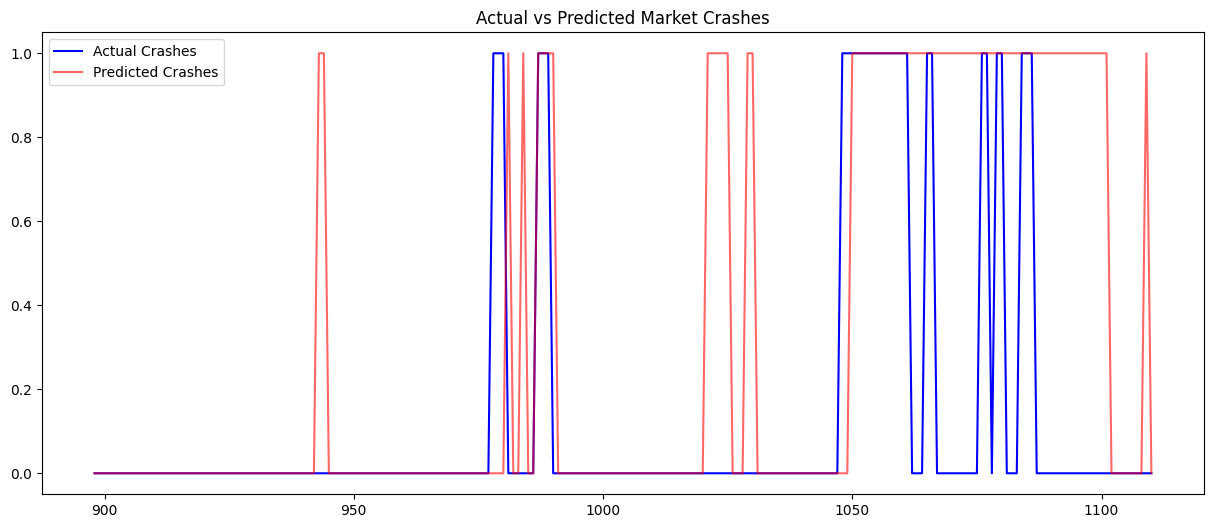

Number of actual crashes: 29
Number of predicted crashes: 68


In [26]:
import matplotlib.pyplot as plt

# Plot actual vs predicted anomalies
plt.figure(figsize=(15, 6))
plt.plot(test_df.index, test_df['Y'], label='Actual Crashes', color='blue')
plt.plot(test_df.index, test_df['predicted_anomaly'], label='Predicted Crashes', color='red', alpha=0.6)
plt.title('Actual vs Predicted Market Crashes')
plt.legend()
plt.show()

# Quick summary of our predictions
print("Number of actual crashes:", test_df['Y'].sum())
print("Number of predicted crashes:", test_df['predicted_anomaly'].sum())

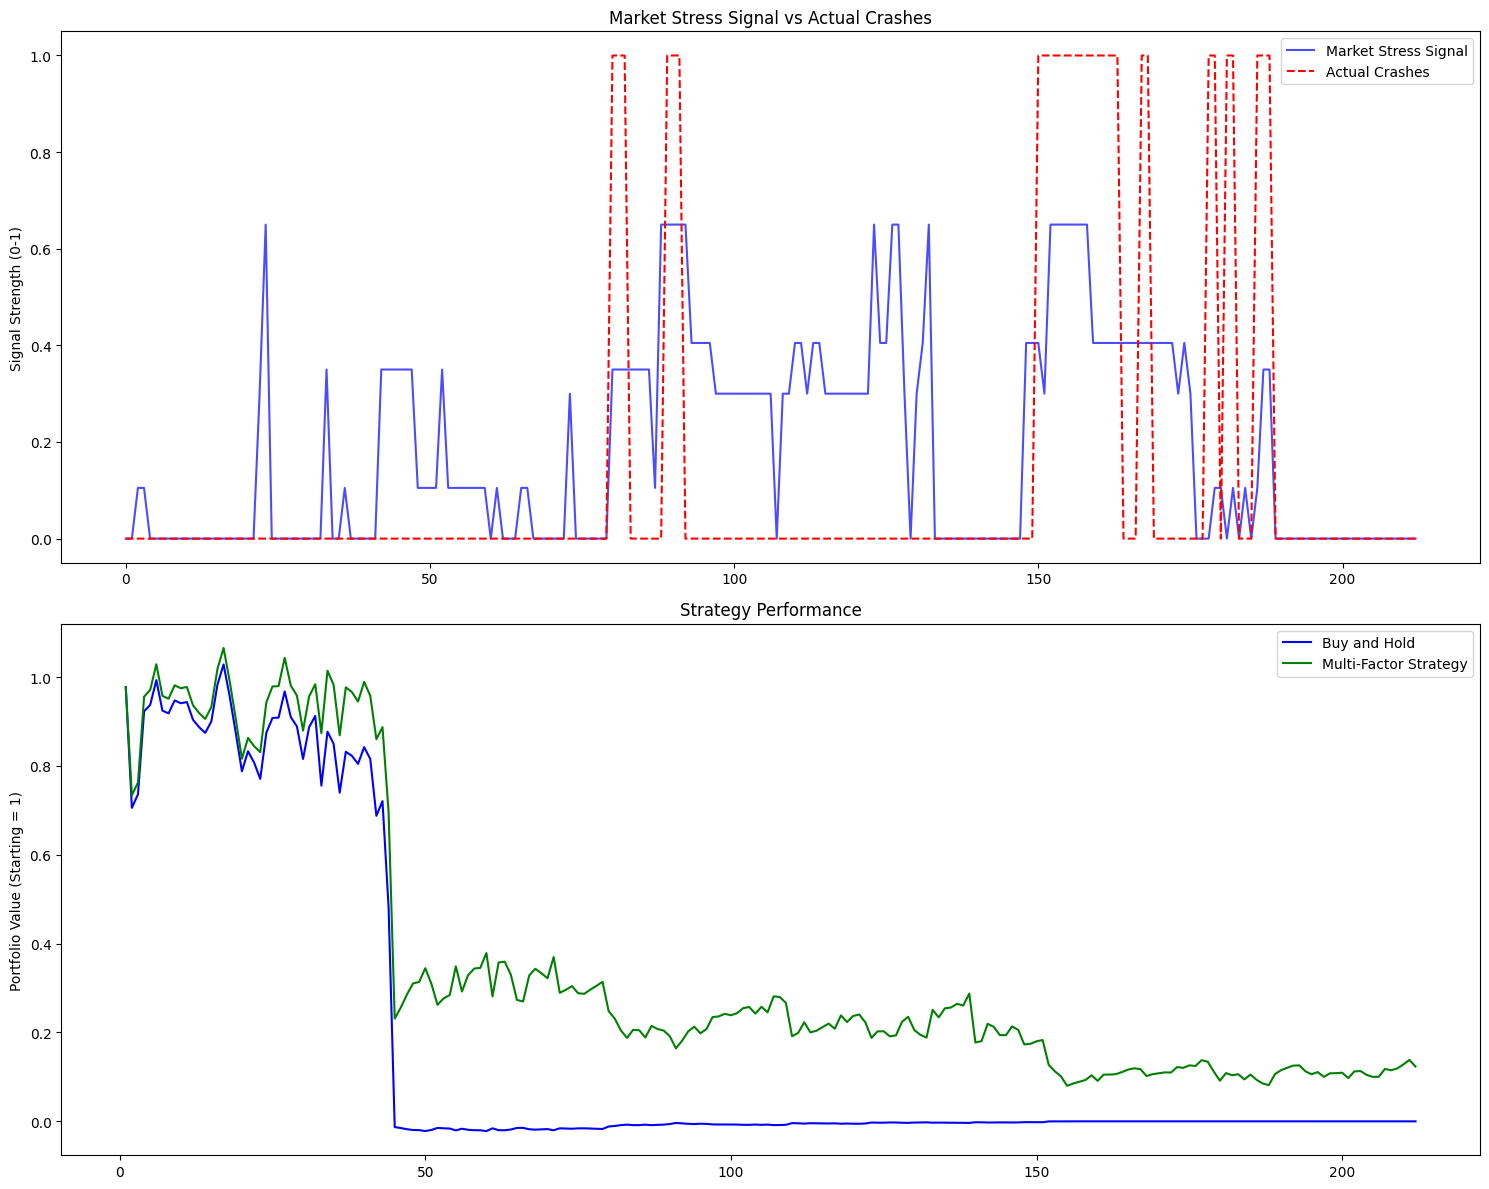


Strategy Performance Metrics:
Time Fully Invested: 46.5%
Average Market Exposure: 81.4%
Strategy Total Return: -87.68%
Market Total Return: -100.01%
Number of Strategy Changes: 57


In [32]:
def calculate_market_signals(df):
    """
    Calculate multiple market stress indicators using financial theory:
    - VIX trends: Higher volatility often precedes market stress
    - Bond yields: Flight to safety during stress shows in yields
    - Currency movements: JPY strengthens in global stress
    - Commodity trends: Economic stress affects raw materials
    """
    # VIX signals - More sophisticated volatility analysis
    df['VIX_stddev'] = df['VIX'].rolling(window=20).std()
    df['vix_signal'] = ((df['VIX'] > df['VIX_MA20'] + df['VIX_stddev']).astype(int) * 0.7 +  # Strong signal
                       (df['VIX'] > df['VIX_MA50']).astype(int) * 0.3)  # Confirmation signal

    # Bond yield signals - Look for yield curve stress
    df['GT10_MA20'] = df['GT10'].rolling(window=20).mean()
    df['yield_volatility'] = df['GT10'].rolling(window=10).std()
    df['bond_signal'] = ((df['GT10'] < df['GT10_MA20'] - df['yield_volatility']).astype(int))

    # Currency stress - Focus on JPY as safe haven
    df['jpy_vol'] = df['JPY'].rolling(window=10).std()
    df['jpy_signal'] = (df['JPY'].pct_change().abs() > 2 * df['jpy_vol']).astype(int)

    # Commodity signal - Look for unusual movements
    df['CRY_vol'] = df['CRY'].rolling(window=20).std()
    df['commodity_signal'] = (abs(df['CRY'].pct_change()) > 2 * df['CRY_vol']).astype(int)

    # Combine signals with adjusted weights based on historical reliability
    df['composite_signal'] = (0.35 * df['vix_signal'] +
                            0.30 * df['bond_signal'] +
                            0.20 * df['jpy_signal'] +
                            0.15 * df['commodity_signal'])

    return df

# Reset index for clearer visualization
test_df = test_df.reset_index()

# Apply our enhanced signals
test_df = calculate_market_signals(test_df)

# Calculate market returns (using -VIX change as proxy)
test_df['market_return'] = -test_df['VIX'].pct_change()

# More nuanced strategy: Reduce exposure gradually based on signal strength
test_df['market_exposure'] = 1 - test_df['composite_signal']
test_df['strategy_return'] = test_df['market_return'] * test_df['market_exposure']

# Calculate cumulative returns properly
test_df['cumulative_market'] = (1 + test_df['market_return']).cumprod()
test_df['cumulative_strategy'] = (1 + test_df['strategy_return']).cumprod()

# Visualization with dates
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Market Stress Signal vs Actual Crashes
ax1.plot(test_df.index, test_df['composite_signal'],
         label='Market Stress Signal', color='blue', alpha=0.7)
ax1.plot(test_df.index, test_df['Y'],
         label='Actual Crashes', color='red', linestyle='--')
ax1.set_title('Market Stress Signal vs Actual Crashes')
ax1.set_ylabel('Signal Strength (0-1)')
ax1.legend()

# Plot 2: Strategy Performance
ax2.plot(test_df.index, test_df['cumulative_market'],
         label='Buy and Hold', color='blue')
ax2.plot(test_df.index, test_df['cumulative_strategy'],
         label='Multi-Factor Strategy', color='green')
ax2.set_title('Strategy Performance')
ax2.set_ylabel('Portfolio Value (Starting = 1)')
ax2.legend()

plt.tight_layout()
plt.show()

# Calculate final returns correctly
final_market_return = (test_df['cumulative_market'].iloc[-1] - 1) * 100
final_strategy_return = (test_df['cumulative_strategy'].iloc[-1] - 1) * 100

print("\nStrategy Performance Metrics:")
print(f"Time Fully Invested: {(test_df['market_exposure'] > 0.9).mean() * 100:.1f}%")
print(f"Average Market Exposure: {test_df['market_exposure'].mean() * 100:.1f}%")
print(f"Strategy Total Return: {final_strategy_return:.2f}%")
print(f"Market Total Return: {final_market_return:.2f}%")
print(f"Number of Strategy Changes: {(test_df['market_exposure'].diff().abs() > 0.1).sum()}")